# Bloque 2: Procesamiento del Lenguaje Natural (NLP)

El objetivo principal de esta segunda parte del miniporyecto, es el de la clasificación automática de texto de currículos, en formato pdf, en categorías laborales predefinidas.

El dataset utilizado para esta sección proviene de la competencia de Kaggle "Jarvis Calling Hiring Contest" y puede acceder a ella mediante el siguiente enlace: https://www.kaggle.com/competitions/jarvis-calling-hiring-contest/overview.

## 1. Análisis Exploratorio de Datos (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter

import plotly.io as pio
pio.renderers.default = "notebook_connected"

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


Veamos entonces la estructura del dataset.

### 1.1 Carga de los datos

In [4]:
PATH = r'C:\DL\nlp_miniproyecto\Proyecto_Deep_Lenguaje_Natural\Proyecto_Deep_Lenguaje_Natural\data\Resume.csv'
df= pd.read_csv(PATH)

In [5]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


De estas dos últimas salidas podemos concluir lo siguiente:

- El dataset está compuesto de `2484` instancias, cada una correspondiente a un currículo, y `4` variables: `ID`, que corresponde al id de los currículos en el formato pdf original; `Resume_str`, que contiene cada currículo en formato string; `Resume_html`, que contiene cada currículo en formato html; y `category`, variable objetivo a predecir, ya que contiene las categorías a las que pertenece cada currículo.

- No hay presencia de valores faltantes en ninguna de las variables.


Cabe resaltar que para este proyecto solo se hará uso de las variables `Resume_str` y `Category`, esto debido a que no es necesario extraer el texto de los pdfs, haciendo inútil a `ID`, ya que su información ya está almacenada en `Resume_str`.

In [7]:
df=df.drop(columns=['ID', 'Resume_html'])

In [8]:
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


### 1.2 Visualización de las categorías

In [9]:
N_CATS    = df['Category'].nunique()
N_DOCS    = len(df)
TOP_N     = 20          
TEMPLATE  = 'plotly_white'
H_PER_CAT = 28          
H_MIN     = 400


def cat_height(n=N_CATS, per=H_PER_CAT, minimum=H_MIN):
    return max(minimum, n * per)


In [16]:
class_counts = (df['Category']
                .value_counts()
                .reset_index()
                .rename(columns={'index': 'Category', 'count': 'Conteo'}))
class_counts = class_counts.sort_values('Conteo', ascending=True)

fig1 = px.bar(
    class_counts,
    x='Conteo',
    y='Category',
    orientation='h',
    text='Conteo',
    color='Category',
    color_discrete_sequence=px.colors.qualitative.D3,
    title='Distribución de clases (Category)',
    template=TEMPLATE,
)
fig1.update_traces(textposition='outside')
fig1.update_layout(
    height=cat_height(),
    showlegend=False,
    xaxis_title='Número de instancias',
    yaxis_title='',
    margin=dict(l=160, r=60, t=60, b=40),
)
fig1.show()

Como podemos ver en el barplot, las categorías cuentan con un número similar de registros, excepto `AGRICULTURE`, `AUTOMOBILE` y `BPO`, esto puede llegar a ser un problema al momento del entrenamiento ya que los modelos tendrán poca información de estas clases en particular.

### 1.3 Preprocesamiento y visualización de los textos

Antes de hacer un buen análisis visualizando el número de palabras por texto o haciendo histogramas y boxplots, es necesario preprocesar los textos, ya que, al ser tomados directamente de un pdf, estos pueden contar con saltos de línea, tabulaciones, caracteres extraños etc., por lo que la función `preprocess_text` se encarga de esto, además de eliminar las llamadas `stopwords`, que son palabras que no aportan a la clasificación del CV, como por ejemplo: the, and, of, to, a, etc.

Además de estas stopwords, se agregaron otras como `company`, `state`, `name`, `city`, las cuales aparecen como genéricas en todos los currículos, por lo que generan ruido innecesario que podemos eliminar ya que son las palabras que mas se repiten, junto con `experience` y `skills` por pertenecer a la estructura básica de cualquier CV. Por último realiza una tokenización de los textos.

In [11]:
other_stopwords = {
    'company', 'name', 'city', 'state', 'experience', 'skills'
}
def preprocess_text(text):
    """
    Limpia y normaliza texto extraído de PDFs:
    - Elimina saltos de línea y espacios múltiples
    - Convierte a minúsculas
    - Elimina caracteres especiales y números
    - Elimina stopwords
    """
    # Reemplazar saltos de línea y tabulaciones por espacio
    text = re.sub(r'[\n\r\t]+', ' ', text)
    # Eliminar espacios múltiples
    text = re.sub(r' {2,}', ' ', text)
    # Reemplazar '/' por espacio 
    text = re.sub(r'/', ' ', text)
    # Convertir a minúsculas
    text = text.lower().strip()
    # Eliminar caracteres especiales y números (mantener letras y espacios)
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
    # Tokenizar
    tokens = word_tokenize(text)
    # Eliminar stopwords en inglés 
    stop_words = set(stopwords.words('english')) | other_stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

def preprocess_text_str(text):
    """Devuelve el texto limpio como string (para WordCloud y n-gramas)."""
    return ' '.join(preprocess_text(text))


# Aplicar preprocesamiento
df['clean_tokens'] = df['Resume_str'].apply(preprocess_text)
df['clean_text']   = df['Resume_str'].apply(preprocess_text_str)
df['word_count']   = df['clean_tokens'].apply(len)


In [12]:
df.head()

,Resume_str,Category,clean_tokens,clean_text,word_count
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,"[administrator, marketing, associate, administ...",administrator marketing associate administrato...,450
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,"[specialist, operations, summary, versatile, m...",specialist operations summary versatile media ...,484
2,HR DIRECTOR Summary Over 2...,HR,"[director, summary, years, recruiting, plus, y...",director summary years recruiting plus years h...,663
3,HR SPECIALIST Summary Dedica...,HR,"[specialist, summary, dedicated, driven, dynam...",specialist summary dedicated driven dynamic ye...,239
4,HR MANAGER Skill Highlights ...,HR,"[manager, skill, highlights, department, start...",manager skill highlights department startup th...,812


In [13]:
median_wc = df['word_count'].median()
mean_wc   = df['word_count'].mean()

# — Histograma
fig2a = px.histogram(
    df,
    x='word_count',
    nbins=40,
    title='Histograma — palabras por CV',
    template=TEMPLATE,
    labels={'word_count': 'Número de palabras'},
    color_discrete_sequence=['#4A90D9'],
)
fig2a.update_traces(marker_line_color='white', marker_line_width=1)  
fig2a.add_vline(x=median_wc, line_dash='dash', line_color='red',
                annotation_text=f'Mediana: {median_wc:.0f}',
                annotation_position='top right',  
                annotation_yshift=10,
                annotation_xshift=10)
fig2a.add_vline(x=mean_wc, line_dash='dash', line_color='orange',
                annotation_text=f'Media: {mean_wc:.0f}',
                annotation_position='top left',  
                annotation_yshift=10)
fig2a.update_layout(yaxis_title='Frecuencia', height=450)
fig2a.show()

# — Boxplot por categoría
order_box = (df.groupby('Category')['word_count']
             .median()
             .sort_values(ascending=False)
             .index.tolist())

fig2b = px.box(
    df,
    x='word_count',
    y='Category',
    category_orders={'Category': order_box},
    color='Category',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Boxplot — palabras por categoría',
    template=TEMPLATE,
    labels={'word_count': 'Número de palabras', 'Category': ''},
    points='outliers',
)
fig2b.update_layout(
    height=cat_height(),
    showlegend=False,
    margin=dict(l=160, r=40, t=60, b=40),
)
fig2b.show()

print("\nEstadísticas de longitud:")
print(df['word_count'].describe().round(1).to_string())




Estadísticas de longitud:
count    2484.0
mean      549.6
std       253.3
min         0.0
25%       443.0
50%       511.0
75%       635.0
max      3496.0


De estas visualizaciones podemos concluir lo siguiente:

- En promedio estos currículos cuentan con 550 palabras, y además, el 75% de estos cuentan más de 443 palabras, lo cual nos indica que, aún quitando stopwords, cada una de estas hojas de vida tienen una gran cantidad de palabras a ser analizadas por los modelos a implementar.

- Existe un dato atípico de una persona cuyo currículo no cuenta con palabras.

- Viendo los boxplots discriminados por categorías, vemos que no suele variar la cantidad de palabras que tiene un currículo dependiendo de que carrera se esté hablando.

Pasemos ahora con las palabras más frecuentes.

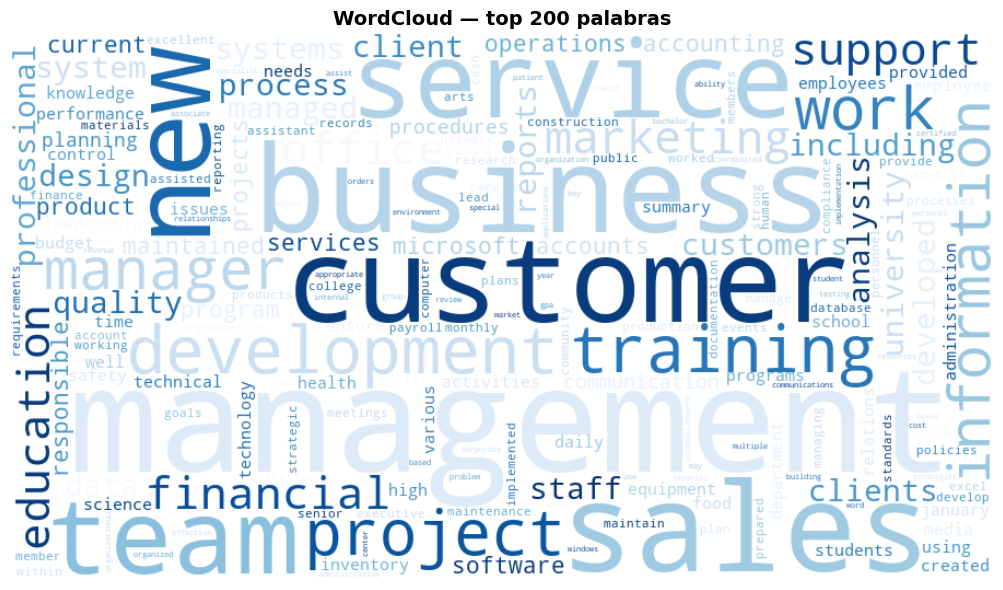

In [14]:
all_tokens = [token for tokens in df['clean_tokens'] for token in tokens]
word_freq  = Counter(all_tokens)
top_words  = word_freq.most_common(TOP_N)
tw_df      = pd.DataFrame(top_words, columns=['Palabra', 'Frecuencia'])
tw_df      = tw_df.sort_values('Frecuencia', ascending=True)

# — Barplot top palabras
fig3 = px.bar(
    tw_df,
    x='Frecuencia',
    y='Palabra',
    orientation='h',
    text='Frecuencia',
    title=f'Top {TOP_N} palabras más frecuentes',
    template=TEMPLATE,
    color='Frecuencia',
    color_continuous_scale='Blues',
)
fig3.update_traces(textposition='outside')
fig3.update_layout(
    height=max(400, TOP_N * 28),
    coloraxis_showscale=False,
    margin=dict(l=120, r=60, t=60, b=40),
)
fig3.show()

# — WordCloud 
vocab_size   = len(word_freq)
wc_max_words = int(np.clip(vocab_size * 0.05, 50, 200))
wc_text      = ' '.join(all_tokens)
wc = WordCloud(width=900, height=500,
               background_color='white',
               colormap='Blues',
               max_words=wc_max_words).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title(f'WordCloud — top {wc_max_words} palabras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Dentro de las palabras más frecuentes encontramos algunas como "sales", "business", "marketing", "development", que en este contexto suelen ser las palabras **cruciales** para diferenciar entre varios oficios. Y a partir de este conteo de palabras se eliminaron las palabras "company", "name", "city", "state", "experience" y "skills", debido a que estas eran las más frecuentes, pero no aportan información relevante.

In [15]:
def get_ngrams(token_lists, n, top_k=TOP_N):
    all_ngrams = [ng for tokens in token_lists for ng in ngrams(tokens, n)]
    freq = Counter(all_ngrams).most_common(top_k)
    return pd.DataFrame(
        [(' '.join(ng), cnt) for ng, cnt in freq],
        columns=['Ngrama', 'Frecuencia']
    ).sort_values('Frecuencia', ascending=True)

bigrams_df  = get_ngrams(df['clean_tokens'], 2)
trigrams_df = get_ngrams(df['clean_tokens'], 3)

# — Bigramas
fig4a = px.bar(
    bigrams_df,
    x='Frecuencia',
    y='Ngrama',
    orientation='h',
    text='Frecuencia',
    title=f'Top {TOP_N} bigramas',
    template=TEMPLATE,
    color='Frecuencia',
    color_continuous_scale='Blues',
)
fig4a.update_traces(textposition='outside')
fig4a.update_layout(
    height=max(400, TOP_N * 28),
    coloraxis_showscale=False,
    margin=dict(l=200, r=60, t=60, b=40),
)
fig4a.show()

# — Trigramas
fig4b = px.bar(
    trigrams_df,
    x='Frecuencia',
    y='Ngrama',
    orientation='h',
    text='Frecuencia',
    title=f'Top {TOP_N} trigramas',
    template=TEMPLATE,
    color='Frecuencia',
    color_continuous_scale='Greens',
)
fig4b.update_traces(textposition='outside')
fig4b.update_layout(
    height=max(400, TOP_N * 28),
    coloraxis_showscale=False,
    margin=dict(l=240, r=60, t=60, b=40),
)
fig4b.show()


Gracias a estos bigramas y trigramas vemos las combinaciones de palabras más comúnes y además las que son cruciales a la hora de diferenciar los oficios, por ejemplo, es muy posible que la combinación "microsoft office suite" se encuentre en el perfil de un ingeniero que de un agricultor por la naturaleza de sus trabajos. 